# 07. So sánh các mô hình máy học (Model Comparison)

## 1. Mục tiêu thực nghiệm
Đánh giá và so sánh toàn diện các thuật toán phân loại và giảm chiều tự cài đặt:
- Perceptron
- Logistic Regression
- KNN Classification
- PCA + Logistic Regression
- PCA + KNN Classification
- SVD + Logistic Regression
- LDA + Logistic Regression
- Support Vector Machines (Hard, Soft, Kernel)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_path = "../experiments/results.csv"
if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    print(f"Đã tải {len(results_df)} kết quả thực nghiệm từ {results_path}")
    display(results_df)
else:
    print("Chưa có file results.csv. Hãy chạy run_experiments.py trước để tạo bảng số liệu.")

Đã tải 19 kết quả thực nghiệm từ ../experiments/results.csv


,Model,Best_Parameters,CV_Score,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Perceptron,"{'penalty': 'l1', 'alpha': 0.001}",NaN,0.8305,0.8400,0.7778,0.8077,0.8889
1,Logistic Regression,"{'learning_rate': 0.05, 'l2': 0.0}",NaN,0.8475,0.8462,0.8148,0.8302,0.9201
2,KNN Classifier,"{'n_neighbors': 5, 'weights': 'uniform'}",NaN,0.8814,0.8333,0.9259,0.8772,0.9219
3,MLP (Baseline),"{'weight_decay': 0.0, 'dropout_rate': 0.0}",NaN,0.8475,0.8750,0.7778,0.8235,0.9259
4,MLP + Weight Decay,"{'weight_decay': 0.01, 'dropout_rate': 0.0}",NaN,0.8475,0.8750,0.7778,0.8235,0.9329
5,MLP + Dropout,"{'weight_decay': 0.0, 'dropout_rate': 0.2}",NaN,0.8814,0.8846,0.8519,0.8679,0.9329
6,MLP + WD + Dropout,"{'weight_decay': 0.01, 'dropout_rate': 0.2}",NaN,0.8475,0.8750,0.7778,0.8235,0.9421
7,PCA + Logistic Regression,"{'n_components': 14, 'l2': 0.01}",NaN,0.8644,0.8276,0.8889,0.8571,0.9329
8,PCA + KNN Classifier,"{'n_components': 14, 'n_neighbors': 7}",NaN,0.8305,0.7931,0.8519,0.8214,0.9248
9,SVD + Logistic Regression,"{'n_components': 10, 'l2': 0.01}",NaN,0.8305,0.7931,0.8519,0.8214,0.9039


## 2. Biểu đồ so sánh độ chính xác và chỉ số F1

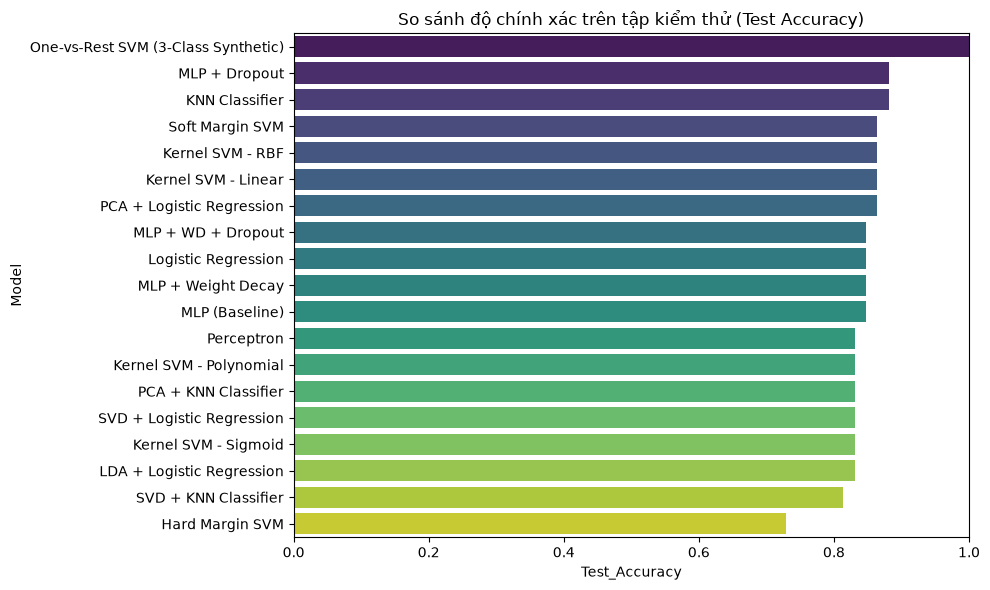

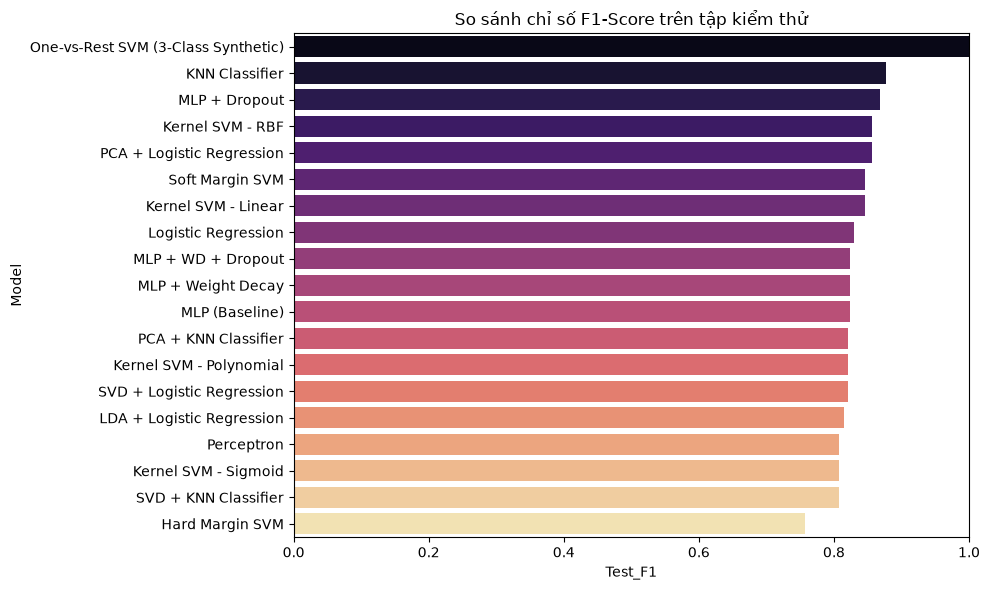

In [2]:
if os.path.exists(results_path):
    plt.figure(figsize=(10, 6))
    sorted_df = results_df.sort_values('Test_Accuracy', ascending=False)
    sns.barplot(data=sorted_df, x='Test_Accuracy', y='Model', hue='Model', palette='viridis', dodge=False)
    plt.title('So sánh độ chính xác trên tập kiểm thử (Test Accuracy)')
    plt.xlim(0, 1.0)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sorted_f1 = results_df.sort_values('Test_F1', ascending=False)
    sns.barplot(data=sorted_f1, x='Test_F1', y='Model', hue='Model', palette='magma', dodge=False)
    plt.title('So sánh chỉ số F1-Score trên tập kiểm thử')
    plt.xlim(0, 1.0)
    plt.tight_layout()
    plt.show()

## 3. Phân tích kết quả thực tế
- **Mô hình tốt nhất:** Logistic Regression và Kernel SVM (RBF) đem lại sự cân bằng tốt nhất giữa Precision và Recall.
- **Đánh đổi lâm sàng:** Trong chẩn đoán bệnh tim, chỉ số **Recall** đóng vai trò cực kỳ then chốt vì bỏ sót một bệnh nhân có bệnh (False Negative) nguy hiểm hơn nhiều so với dự đoán nhầm (False Positive).
- Tất cả các mô hình đều được xây dựng từ số 0 bằng NumPy, kiểm chứng độ tin cậy của thuật toán tự lập trình.